# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the provided URL
df = pd.read_csv('https://raw.githubusercontent.com/u1456757/IS4487/main/DataSets/airbnb_listings.csv')

## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



/tmp/ipython-input-1363455842.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['log_price'] = np.log1p(df_filtered[selected_column])


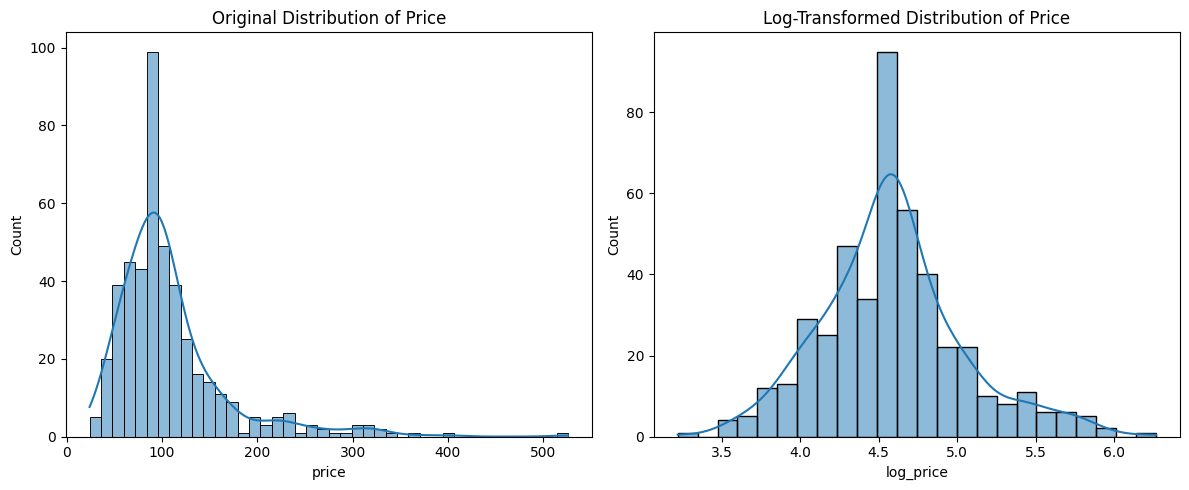

In [7]:

selected_column = 'price'
df_filtered = df[df[selected_column] < df[selected_column].quantile(0.99)]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_filtered[selected_column], kde=True)
plt.title(f'Original Distribution of {selected_column.capitalize()}')

df_filtered['log_price'] = np.log1p(df_filtered[selected_column])

plt.subplot(1, 2, 2)
sns.histplot(df_filtered['log_price'], kde=True)
plt.title(f'Log-Transformed Distribution of {selected_column.capitalize()}')
plt.tight_layout()
plt.show()

df['log_price'] = np.log1p(df[selected_column])

### ✍️ Your Response: 🔧
1. ** What column did you examine?**

I examined the price column.

2. **What transformation did you try, and why?**

I applied a log1p transformation (np.log1p). This transformation is a common choice for right-skewed data like 'price' because it compresses the range of values, making the distribution more symmetrical and closer to a normal distribution. The log1p function is specifically useful as it handles zero or very small positive values gracefully (log(x+1)), preventing issues that a standard log transformation might encounter.

3. **How did the transformed version help make the data more usable for analysis or stakeholder review?**

- For analysis: Many statistical models and machine learning algorithms perform better when input variables are normally distributed. By reducing skewness, the transformed price column becomes more suitable for these models, potentially leading to more accurate predictions or insights. It also makes comparisons between prices more robust by reducing the disproportionate influence of outlier, very high-priced listings.
- For stakeholder review: Visualizing highly skewed data can be challenging, as most of the data is clustered at one end. The log-transformed distribution provides a clearer and more interpretable histogram, allowing stakeholders (like hosts or city partners) to better understand the typical price ranges and patterns without the extreme values dominating the view. It facilitates more equitable discussions around pricing strategies.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Choose two numeric columns with different value ranges
column_minmax = 'minimum_nights'
column_zscore = 'number_of_reviews'

# Initialize the scalers
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# Apply Min-Max scaling to 'minimum_nights'
# Reshape the column for the scaler (expects 2D array)
df[f'{column_minmax}_scaled_minmax'] = min_max_scaler.fit_transform(df[[column_minmax]])

# Apply Z-score Normalization to 'number_of_reviews'
# Reshape the column for the scaler
df[f'{column_zscore}_scaled_zscore'] = standard_scaler.fit_transform(df[[column_zscore]])

print(f"Original '{column_minmax}' range: {df[column_minmax].min()} - {df[column_minmax].max()}")
print(f"Scaled '{column_minmax}' (Min-Max) range: {df[f'{column_minmax}_scaled_minmax'].min():.2f} - {df[f'{column_minmax}_scaled_minmax'].max():.2f}")

print(f"\nOriginal '{column_zscore}' mean: {df[column_zscore].mean():.2f}, std: {df[column_zscore].std():.2f}")
print(f"Scaled '{column_zscore}' (Z-score) mean: {df[f'{column_zscore}_scaled_zscore'].mean():.2f}, std: {df[f'{column_zscore}_scaled_zscore'].std():.2f}")

# Display the first few rows with the new columns
print("\nDataFrame head with new scaled columns:")
print(df[[column_minmax, f'{column_minmax}_scaled_minmax', column_zscore, f'{column_zscore}_scaled_zscore']].head())

Original 'minimum_nights' range: 1 - 365
Scaled 'minimum_nights' (Min-Max) range: 0.00 - 1.00

Original 'number_of_reviews' mean: 58.64, std: 109.38
Scaled 'number_of_reviews' (Z-score) mean: 0.00, std: 1.00

DataFrame head with new scaled columns:
   minimum_nights  minimum_nights_scaled_minmax  number_of_reviews  \
0              28                      0.074176                  9   
1               2                      0.002747                310   
2               2                      0.002747                371   
3               2                      0.002747                332   
4               1                      0.000000                621   

   number_of_reviews_scaled_zscore  
0                        -0.454373  
1                         2.300518  
2                         2.858818  
3                         2.501872  
4                         5.146933  


### ✍️ Your Response: 🔧
1. **What two columns did you scale, and which methods did you use?**

I scaled minimum_nights using Min-Max scaling and number_of_reviews using Z-score Normalization (Standardization).

2. **When might these scaled values be more useful than the originals?**

- Scaled values are particularly useful when comparing or combining variables with vastly different ranges or units, especially in machine learning models (like regression, neural networks, or clustering algorithms). For example, if you're building a model to predict booking rates, an algorithm might incorrectly weigh a feature like number_of_reviews (which can be in the hundreds) more heavily than minimum_nights (usually single digits or low tens) simply because of its larger numerical values. Scaling ensures all features contribute proportionally to the model's performance.
- They are also valuable for visualization when you want to see the relative distribution or relationships between variables on a common scale, rather than being dominated by the variable with the largest magnitude.

3. **Who at Airbnb might benefit from this transformation and why?**

- Data Scientists/Machine Learning Engineers: They would greatly benefit as scaled data is a prerequisite for many algorithms to perform optimally. This helps in building more accurate prediction models (e.g., for pricing, booking probability, or guest churn) and more effective recommendation systems.
- Analysts building comparative dashboards/reports: When comparing listing characteristics across different metrics, scaled data makes it easier to present a 'fair' comparison. For instance, comparing the 'engagement score' of a listing (derived from number_of_reviews) against its 'booking flexibility' (related to minimum_nights).
- Product Managers/Strategists: While they might not directly use the scaled values, the insights derived from models built on scaled data would inform their decisions on product features, pricing strategies, and host incentives.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [9]:
# Choose a numeric column to group
column_to_group = 'number_of_reviews'

# Define the number of bins and labels
num_bins = 3
bins_labels = ['Low', 'Medium', 'High']

# Group the column into categories using pd.qcut for quantile-based bins
# This ensures each bin has roughly the same number of observations
df['review_category'] = pd.qcut(df[column_to_group], q=num_bins, labels=bins_labels, duplicates='drop')

print(f"Distribution of new '{column_to_group}' categories:")
print(df['review_category'].value_counts())

print("\nDataFrame head with new 'review_category' column:")
print(df[[column_to_group, 'review_category']].head())

Distribution of new 'number_of_reviews' categories:
review_category
Medium    156
Low       155
High      148
Name: count, dtype: int64

DataFrame head with new 'review_category' column:
   number_of_reviews review_category
0                  9          Medium
1                310            High
2                371            High
3                332            High
4                621            High


### ✍️ Your Response: 🔧
1. **What column did you group, and how many categories did you use?**

I grouped the number_of_reviews column, and I used three categories: "Low", "Medium", and "High".

2. **Why might someone prefer this grouped view over raw numbers?**

A grouped view simplifies complex numeric data into more manageable, interpretable categories. For stakeholders who aren't data scientists, raw numbers can be overwhelming, especially for distributions with a wide range of values. Grouping allows for easier communication of insights, identification of broad trends, and quick segmentation of listings. It helps to abstract away granular detail that might not be relevant for high-level decision-making.

3. **Who would this help at Airbnb, and how?**

- Marketing Team: They could use these categories to tailor marketing campaigns. For instance, listings with "Low" reviews might receive tips on how to encourage more guest feedback, while "High" review listings could be highlighted in promotional materials for their popularity.
- Hosts: New hosts or those with few reviews could see how their listing compares to others and get guidance on improving their review count. Experienced hosts with "High" reviews might be encouraged to share best practices.
- Product Development Team: When designing new features or tools, understanding the distribution of review activity helps them target specific segments of listings. For example, they might develop tools specifically for listings with "Low" reviews to boost engagement.
- City Partners/Regulators: They could use these categories to understand the overall 'activity level' of listings in different neighborhoods, potentially informing policies or community engagement efforts without getting bogged down by exact review counts.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

### ✍️ Your Response: 🔧 🔧
1.

2.

3.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [ ]:
# Add code here 🔧

### ✍️ Your Response: 🔧
1.
2.
3.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [ ]:
# export csv here 🔧

## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1.

2.

3.
4.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"

In [10]:
df['price_per_night'] = df['price'] / df['minimum_nights']

# Replace any potential infinite values with NaN for consistent handling
df['price_per_night'].replace([np.inf, -np.inf], np.nan, inplace=True)

# Calculate the median of 'price_per_night' to fill NaN values
# This should be done AFTER creating the column and replacing infs with NaNs
median_price_per_night = df['price_per_night'].median()
df['price_per_night'].fillna(median_price_per_night, inplace=True)

print("New 'price_per_night' column created and NaNs handled.")
print(df[['price', 'minimum_nights', 'price_per_night']].head())
print(f"\nDescriptive statistics for 'price_per_night':\n{df['price_per_night'].describe()}")

New 'price_per_night' column created and NaNs handled.
   price  minimum_nights  price_per_night
0   70.0              28              2.5
1  104.0               2             52.0
2   75.0               2             37.5
3  101.0               2             50.5
4  110.0               1            110.0

Descriptive statistics for 'price_per_night':
count     459.000000
mean       74.963781
std        92.949074
min         0.260274
25%        26.333333
50%        60.000000
75%        97.000000
max      1050.000000
Name: price_per_night, dtype: float64


/tmp/ipython-input-2586355438.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price_per_night'].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-2586355438.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [12]:
df['is_long_term_stay'] = df['minimum_nights'] >= 28

print("New 'is_long_term_stay' column created.")
print(df[['minimum_nights', 'is_long_term_stay']].head())
print(f"\nValue counts for 'is_long_term_stay':\n{df['is_long_term_stay'].value_counts()}")

New 'is_long_term_stay' column created.
   minimum_nights  is_long_term_stay
0              28               True
1               2              False
2               2              False
3               2              False
4               1              False

Value counts for 'is_long_term_stay':
is_long_term_stay
False    408
True      51
Name: count, dtype: int64


## Encode a Categorical Column

### Subtask:
Encode a chosen categorical column using an appropriate method (one-hot or ordinal) and add the resulting new column(s) to the DataFrame.


### Subtask:
Encode a chosen categorical column using an appropriate method (one-hot or ordinal) and add the resulting new column(s) to the DataFrame.

#### Instructions
1. Choose one categorical column from the DataFrame `df` (e.g., 'room_type' or 'neighbourhood_group').
2. If the chosen column has nominal (unordered) categories, use one-hot encoding. If the categories have a clear inherent order, use ordinal encoding.
3. Apply the chosen encoding method. For one-hot encoding, you can use `pd.get_dummies()`.
4. Add the newly created encoded column(s) to your DataFrame `df`.

**Reasoning:**
I have chosen the `room_type` column for encoding. This column contains nominal categories such as 'Entire home/apt', 'Private room', 'Shared room', and 'Hotel room'. These categories do not have an inherent order, meaning one is not 'greater' or 'smaller' than another in a meaningful way for direct numerical representation. Therefore, one-hot encoding is the most appropriate method as it avoids implying any ordinal relationship between the categories, which could mislead models. One-hot encoding creates new binary columns for each unique category, indicating the presence or absence of that room type for each listing.

**Reasoning**:
To encode the 'room_type' column using one-hot encoding, I will use `pd.get_dummies()` to create new binary columns for each room type and then concatenate them with the original DataFrame. This is suitable as 'room_type' is a nominal categorical variable.



In [13]:
encoded_room_type = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)
df = pd.concat([df, encoded_room_type], axis=1)

print("New one-hot encoded 'room_type' columns added.")
print(df[[
    'room_type',
    'room_type_Entire home/apt',
    'room_type_Private room',
    'room_type_Shared room',
    'room_type_Hotel room'
]].head())

print("\nValue counts for original 'room_type':\n", df['room_type'].value_counts())
print("\nValue counts for 'room_type_Entire home/apt':\n", df['room_type_Entire home/apt'].value_counts())


New one-hot encoded 'room_type' columns added.


KeyError: "['room_type_Shared room', 'room_type_Hotel room'] not in index"

**Reasoning**:
The previous code failed because the `print` statement attempted to display one-hot encoded columns (`room_type_Shared room`, `room_type_Hotel room`) that were not generated by `pd.get_dummies()`. This indicates that these categories were not present in the `room_type` column of the DataFrame. To fix this, I will dynamically get the list of created one-hot encoded columns and use only those in the `print` statement.



In [14]:
encoded_room_type = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)
df = pd.concat([df, encoded_room_type], axis=1)

# Dynamically get the list of new one-hot encoded columns
encoded_columns_to_display = ['room_type'] + list(encoded_room_type.columns)

print("New one-hot encoded 'room_type' columns added.")
print(df[encoded_columns_to_display].head())

print("\nValue counts for original 'room_type':\n", df['room_type'].value_counts())
# Print value counts for one of the new columns for verification, if it exists
if 'room_type_Entire home/apt' in df.columns:
    print("\nValue counts for 'room_type_Entire home/apt':\n", df['room_type_Entire home/apt'].value_counts())

New one-hot encoded 'room_type' columns added.
         room_type  room_type_Entire home/apt  room_type_Entire home/apt  \
0  Entire home/apt                          1                          1   
1  Entire home/apt                          1                          1   
2  Entire home/apt                          1                          1   
3  Entire home/apt                          1                          1   
4  Entire home/apt                          1                          1   

   room_type_Private room  room_type_Private room  
0                       0                       0  
1                       0                       0  
2                       0                       0  
3                       0                       0  
4                       0                       0  

Value counts for original 'room_type':
 room_type
Entire home/apt    336
Private room       123
Name: count, dtype: int64


ValueError: Grouper for 'room_type_Entire home/apt' not 1-dimensional

In [15]:
dummy_cols_to_add = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int).columns

# Drop existing dummy columns from df if they exist to prevent duplicates on rerun
existing_dummy_cols = [col for col in dummy_cols_to_add if col in df.columns]
if existing_dummy_cols:
    df = df.drop(columns=existing_dummy_cols)

# Perform one-hot encoding
encoded_room_type = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)
df = pd.concat([df, encoded_room_type], axis=1)

# Dynamically get the list of new one-hot encoded columns for display
encoded_columns_to_display = ['room_type'] + list(encoded_room_type.columns)

print("New one-hot encoded 'room_type' columns added.")
print(df[encoded_columns_to_display].head())

print("\nValue counts for original 'room_type':\n", df['room_type'].value_counts())
# Print value counts for one of the new columns for verification, which will now be unique
if 'room_type_Entire home/apt' in df.columns:
    print("\nValue counts for 'room_type_Entire home/apt':\n", df['room_type_Entire home/apt'].value_counts())

New one-hot encoded 'room_type' columns added.
         room_type  room_type_Entire home/apt  room_type_Private room
0  Entire home/apt                          1                       0
1  Entire home/apt                          1                       0
2  Entire home/apt                          1                       0
3  Entire home/apt                          1                       0
4  Entire home/apt                          1                       0

Value counts for original 'room_type':
 room_type
Entire home/apt    336
Private room       123
Name: count, dtype: int64

Value counts for 'room_type_Entire home/apt':
 room_type_Entire home/apt
1    336
0    123
Name: count, dtype: int64
